In [1]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

#from catboost import CatBoostRegressor

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [76]:
#%pip install torch

считывание данных из `C:\Users\limon\OneDrive\Рабочий стол\Курсовая\abob_progs\ANN\DATA`

# Data collection

In [24]:
def load_data(ordinary_data, dir, data):
    path = f"{ordinary_data}/{dir}/{data}"
    with open(path, 'r', encoding='utf-8') as file:
        lines = file.readlines()[1:]  # Skip the first line (header)
    data_list = []
    for line in lines:
        values = list(map(float, line.split()))
        data_list.append(values)
    return data_list


def go_all_data(ordinary_data, dirs, nu_e_data):
    all_data = []
    for dir in dirs:
        data = load_data(ordinary_data, dir, nu_e_data)
        all_data.extend(data)
    return all_data



In [25]:
ordinary_data = "C:/Users/limon/OneDrive/Рабочий стол/Курсовая/abob_progs/ANN/DATA"

first_day = 12
last_day  =  17

dirs = [f"{day}-04-2026" for day in range(first_day, last_day + 1)]

nu_e_data = "fort.31"
forces_data = "fort.42"

In [26]:
X_data = go_all_data(ordinary_data, dirs, nu_e_data)
X_data = np.array(X_data)

Y_data = go_all_data(ordinary_data, dirs, forces_data)
Y_data = np.array(Y_data)


X_train, X_val_test, Y_train, Y_val_test = train_test_split(X_data, Y_data, test_size=0.2, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_val_test, Y_val_test, test_size=0.5, random_state=42)

In [27]:
#count = 0
#X_new, Y_new = [], []
#for (X, Y) in zip(X_data, Y_data):
#    E = X[0::2]
#    nu = X[1::2]
#    if np.all(nu < 0.45) and np.all(E < 2.3): 
#        count += 1
#        X_new.append(X)
#        Y_new.append(Y)
#X_new, Y_new = np.array(X_new), np.array(Y_new)

#X_train, X_val_test, Y_train, Y_val_test = train_test_split(X_new, Y_new, test_size=0.2, random_state=42)
#X_val, X_test, Y_val, Y_test = train_test_split(X_val_test, Y_val_test, test_size=0.5, random_state=42)
#X_new.shape, Y_new.shape, count

In [28]:
def average_absolute_percentage_error(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)))

def average_squared_percentage_error(y_true, y_pred):
    #return (np.sum((y_true - y_pred) ** 2) / np.sum(y_true ** 2 )) ** 0.5
    return np.mean(np.sum((y_true - y_pred) ** 2, axis=1) / np.sum(y_true ** 2, axis=1)) ** 0.5

# PCA

Из прошлых работ известно, что с помощью *PCA* можно сжать векторы усилий

In [29]:
# PCA for train, val, test
def make_pca(n_components, Y_train, Y_val, Y_test):
    pca = PCA(n_components=n_components)

    Y_train_pca = pca.fit_transform(Y_train)
    Y_val_pca = pca.transform(Y_val)
    Y_test_pca = pca.transform(Y_test)

    return Y_train_pca, Y_val_pca, Y_test_pca, pca

# check PCA for different n_components and print metrics
def check_pca(n_components_list, Y_train, Y_val, Y_test):
    for n_components in n_components_list:
        
        Y_train_pca, Y_val_pca, Y_test_pca, pca = make_pca(n_components, Y_train, Y_val, Y_test)

        print(f"NUMBER OF COMPONENTS: {n_components} is done.")

        # Восстановление данных
        Y_train_reconstructed = pca.inverse_transform(Y_train_pca)
        Y_val_reconstructed = pca.inverse_transform(Y_val_pca)
        Y_test_reconstructed = pca.inverse_transform(Y_test_pca)

        # Метрики для train
        mse_train = mean_squared_error(Y_train, Y_train_reconstructed)
        mae_train = mean_absolute_error(Y_train, Y_train_reconstructed)
        r2_train = r2_score(Y_train, Y_train_reconstructed)

        print(f"\nTrain Reconstruction - MSE: {mse_train:.2e}, MAE: {mae_train:.2e}, R²: {r2_train:.4f}")

        # Метрики для val
        mse_val = mean_squared_error(Y_val, Y_val_reconstructed)
        mae_val = mean_absolute_error(Y_val, Y_val_reconstructed)
        r2_val = r2_score(Y_val, Y_val_reconstructed)

        print(f"Val Reconstruction - MSE: {mse_val:.2e}, MAE: {mae_val:.2e}, R²: {r2_val:.4f}")

        # Метрики для test
        mse_test = mean_squared_error(Y_test, Y_test_reconstructed)
        mae_test = mean_absolute_error(Y_test, Y_test_reconstructed)
        r2_test = r2_score(Y_test, Y_test_reconstructed)

        print(f"Test Reconstruction - MSE: {mse_test:.2e}, MAE: {mae_test:.2e}, R²: {r2_test:.4f}")

        print(f"Train shape: {X_train.shape}, PCA shape: {Y_train_pca.shape}")
        print(f"Val shape: {X_val.shape}, PCA shape: {Y_val_pca.shape}")
        print(f"Test shape: {X_test.shape}, PCA shape: {Y_test_pca.shape}\n")
        print("-" * 50)


In [30]:
# В PCA надо подавать элменеты с матожиданием 0 и стандартным отклонением 1, поэтому стандартизируем данные перед PCA
y_scaler = StandardScaler()
Y_train_scaled = y_scaler.fit_transform(Y_train)
Y_val_scaled = y_scaler.transform(Y_val)
Y_test_scaled = y_scaler.transform(Y_test)

n_components_list = [i for i in range(1, Y_train.shape[1] + 1)]
check_pca(n_components_list, Y_train_scaled, Y_val_scaled, Y_test_scaled)

NUMBER OF COMPONENTS: 1 is done.

Train Reconstruction - MSE: 1.47e-01, MAE: 2.68e-01, R²: 0.8530
Val Reconstruction - MSE: 1.47e-01, MAE: 2.69e-01, R²: 0.8541
Test Reconstruction - MSE: 1.46e-01, MAE: 2.66e-01, R²: 0.8538
Train shape: (120826, 8), PCA shape: (120826, 1)
Val shape: (15103, 8), PCA shape: (15103, 1)
Test shape: (15104, 8), PCA shape: (15104, 1)

--------------------------------------------------
NUMBER OF COMPONENTS: 2 is done.

Train Reconstruction - MSE: 1.17e-02, MAE: 8.41e-02, R²: 0.9883
Val Reconstruction - MSE: 1.17e-02, MAE: 8.40e-02, R²: 0.9884
Test Reconstruction - MSE: 1.17e-02, MAE: 8.40e-02, R²: 0.9882
Train shape: (120826, 8), PCA shape: (120826, 2)
Val shape: (15103, 8), PCA shape: (15103, 2)
Test shape: (15104, 8), PCA shape: (15104, 2)

--------------------------------------------------
NUMBER OF COMPONENTS: 3 is done.

Train Reconstruction - MSE: 4.70e-03, MAE: 5.02e-02, R²: 0.9953
Val Reconstruction - MSE: 4.71e-03, MAE: 5.00e-02, R²: 0.9953
Test Recon

In [31]:
Y_train_scaled, Y_val_scaled, Y_test_scaled


(array([[-2.77854943, -0.97291602,  2.12532398, ...,  1.98551886,
         -0.68113049, -2.48571407],
        [ 0.5529631 , -0.56451781,  0.10076354, ...,  0.22631419,
         -0.41300537,  0.12577434],
        [ 0.5529631 ,  0.95354064, -0.86214046, ..., -0.93791071,
          0.8409316 ,  0.740569  ],
        ...,
        [ 0.5529631 , -1.10159648,  0.2139947 , ...,  0.43956588,
         -1.23422826,  0.20277963],
        [ 0.5529631 ,  0.63696255, -0.72918521, ..., -0.78047414,
          0.42547266,  0.740569  ],
        [ 0.5529631 ,  1.35727166, -1.04766756, ..., -1.1316976 ,
          1.36270154,  0.740569  ]], shape=(120826, 8)),
 array([[ 0.5529631 ,  0.74031179, -0.71401345, ..., -0.78861635,
          0.56521225,  0.740569  ],
        [ 0.5529631 ,  1.51285788, -1.33107163, ..., -1.2962866 ,
          1.53051361,  0.740569  ],
        [-1.38283106, -0.87011518,  1.31510018, ...,  1.30221067,
         -0.60711749, -1.43660179],
        ...,
        [ 0.5529631 ,  0.89620582, 

In [109]:
# сжимаем до 4 компонент
n_components = 4
Y_train_pca, Y_val_pca, Y_test_pca, pca = make_pca(n_components, Y_train_scaled, Y_val_scaled, Y_test_scaled)
Y_train_pca, Y_val_pca, Y_test_pca

(array([[ 5.07544634, -1.93238237, -0.19278774,  0.12243386],
        [ 0.38332815,  0.82131476,  0.31960674, -0.13583701],
        [-2.39596179, -0.22265007, -0.07013043,  0.05232398],
        ...,
        [ 1.33995872,  1.60393295,  0.02234303, -0.13609528],
        [-1.82819461,  0.16246646, -0.1533094 ,  0.0635235 ],
        [-3.11691653, -0.7067095 ,  0.02583667,  0.02794798]],
       shape=(120826, 4)),
 array([[-1.99712731,  0.0173327 , -0.06495226,  0.10634846],
        [-3.43109958, -0.82065967, -0.13176089, -0.14012012],
        [ 3.23344746, -0.74854852,  0.04577558, -0.01222228],
        ...,
        [-2.24082449, -0.25426196,  0.189117  ,  0.27430311],
        [-0.91149665,  0.76612198, -0.25038461,  0.11131204],
        [ 1.53703736,  0.71730152,  0.29033218, -0.18420421]],
       shape=(15103, 4)),
 array([[ 0.2072378 ,  0.86691604,  0.1791162 , -0.10526942],
        [-0.37136447,  1.14830166, -0.35905175,  0.08538467],
        [ 0.87510769,  1.0399963 ,  0.25606787, -0.

In [110]:
#функция для обратного преобразования PCA
def inverse_pca(Y_pca, pca, scaler):
    Y_reconstructed = pca.inverse_transform(Y_pca)
    Y_reconstructed = scaler.inverse_transform(Y_reconstructed)
    return Y_reconstructed

In [111]:

def enu_to_lame(X):
    """(E, nu) -> (lambda, mu). X shape: (N, 8) -> [lambda0, mu0, lambda1, mu1, ...]"""
    E = X[:, 0::2]
    nu = X[:, 1::2]
    
    # Защита от ν = -1 или ν = 0.5 (физически недопустимо, но бывает в шумных данных)
    nu_safe = np.clip(nu, -0.99, 0.49)
    
    mu = E / (2.0 * (1.0 + nu_safe))
    lam = (E * nu_safe) / ((1.0 + nu_safe) * (1.0 - 2.0 * nu_safe))
    
    X_lame = np.zeros_like(X)
    X_lame[:, 0::2] = lam
    X_lame[:, 1::2] = mu
    return X_lame

def lame_to_enu(X_lame):
    """(lsmbda, mu) -> (E, ν)"""
    lam = X_lame[:, 0::2]
    mu = X_lame[:, 1::2]
    
    denom = lam + mu + EPS
    E = mu * (3.0 * lam + 2.0 * mu) / denom
    nu = lam / (2.0 * denom)
    
    X_enu = np.zeros_like(X_lame)
    X_enu[:, 0::2] = E
    X_enu[:, 1::2] = nu
    return X_enu

# $ (E, \nu) \to forces $

## TRain $(E, \nu)$

In [112]:
#X_train = enu_to_lame(X_train)
#X_val   = enu_to_lame(X_val)
#X_test  = enu_to_lame(X_test)


x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_val_scaled = x_scaler.transform(X_val)
X_test_scaled = x_scaler.transform(X_test)

x_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(Y_train_pca, dtype=torch.float32)
x_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(Y_val_pca, dtype=torch.float32)
x_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(Y_test_pca, dtype=torch.float32)

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

x_train_tensor.shape, y_train_tensor.shape

(torch.Size([120826, 8]), torch.Size([120826, 4]))

In [90]:
class EnuToForces(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(EnuToForces, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            #nn.GELU(),
            #nn.Linear(512, 256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        x = self.model(x)
        return x
    
    

In [91]:
def train(model, 
          train_loader, 
          val_loader, 
          num_epochs, 
          learning_rate, 
          limit, 
          device='cpu', 
          history=None, 
          factor=0.5, 
          patience=7):
    
    criterion = nn.MSELoss()
    optimizer = Adam(model.parameters(), lr=learning_rate)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=factor, patience=patience,  min_lr=1e-7)
     
    model.to(device)
    if history is None:
        history = {"train_loss": [], "val_loss": []}
    # train
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x_batch.size(0)

        train_loss /= len(train_loader.dataset)

        # validate
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model(x_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * x_batch.size(0)
        val_loss /= len(val_loader.dataset)
        scheduler.step(val_loss)
        # history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        # print metrics
        if epoch % limit == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch }/{num_epochs}, Train Loss: {train_loss:.6e}, Val Loss: {val_loss:.6e}, LR: {optimizer.param_groups[0]['lr']:.6e}")
    return model, history, optimizer.param_groups[0]['lr']

In [92]:
from pathlib import Path
#from typing import Dict, Any, Optional

# функция для построения графиков истории обучения
def show_history(
    history,
    train_loss: str = "train_loss",
    val_loss: str = "val_loss",
    train_label: str = "Train Loss",
    val_label: str = "Val Loss",
    title: str = "Training and Validation Loss",
    save: bool = False,
    file_name: str = "history.png",
    path: str = "",
    ) -> None:
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history[train_loss], label=train_label)
    plt.plot(history[val_loss], label=val_label)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid()

    if save:
        # Создаем путь с помощью pathlib
        file_path = Path(path) / file_name if path else Path(file_name)
        
        # Создаем директорию, если она не существует
        file_path.parent.mkdir(parents=True, exist_ok=True)
        
        # Сохраняем файл
        plt.savefig(file_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {file_path.absolute()}")
    plt.show()


In [93]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
history = {"train_loss": [], "val_loss": []}
model = EnuToForces(input_dim=X_train.shape[1], output_dim=n_components)

In [94]:
model, history, _ = train(model, train_loader, val_loader, num_epochs=150, learning_rate=1e-3, limit=10, device=device, history=history, factor=0.5, patience=7)

Epoch 0/150, Train Loss: 1.090106e-01, Val Loss: 8.989092e-03, LR: 1.000000e-03
Epoch 10/150, Train Loss: 1.197118e-03, Val Loss: 8.249613e-04, LR: 1.000000e-03
Epoch 20/150, Train Loss: 7.698735e-04, Val Loss: 1.215558e-03, LR: 5.000000e-04
Epoch 30/150, Train Loss: 2.125126e-04, Val Loss: 2.264491e-04, LR: 5.000000e-04
Epoch 40/150, Train Loss: 7.568546e-05, Val Loss: 9.599262e-05, LR: 2.500000e-04
Epoch 50/150, Train Loss: 6.628612e-05, Val Loss: 1.413019e-04, LR: 2.500000e-04
Epoch 60/150, Train Loss: 2.566609e-05, Val Loss: 5.058987e-05, LR: 1.250000e-04
Epoch 70/150, Train Loss: 1.491641e-05, Val Loss: 2.087253e-05, LR: 6.250000e-05
Epoch 80/150, Train Loss: 1.404054e-05, Val Loss: 1.629682e-05, LR: 6.250000e-05
Epoch 90/150, Train Loss: 1.214950e-05, Val Loss: 1.800932e-05, LR: 3.125000e-05
Epoch 100/150, Train Loss: 8.568445e-06, Val Loss: 1.306600e-05, LR: 3.125000e-05
Epoch 110/150, Train Loss: 8.271942e-06, Val Loss: 1.251956e-05, LR: 3.125000e-05
Epoch 120/150, Train Loss: 

In [95]:
model.eval()

for x, y in val_loader:
    y = y.to(device)
    x = x.to(device)
    pred_y = model(x)
    print(pred_y[:5])
    print(y[:5])
    break

tensor([[-1.9974,  0.0179],
        [-3.4342, -0.8216],
        [ 3.2340, -0.7499],
        [ 1.4532,  1.5982],
        [ 0.7767,  1.5239]], device='cuda:0', grad_fn=<SliceBackward0>)
tensor([[-1.9971,  0.0173],
        [-3.4311, -0.8207],
        [ 3.2334, -0.7485],
        [ 1.4583,  1.6151],
        [ 0.7733,  1.5188]], device='cuda:0')


Plot saved to: C:\Users\limon\OneDrive\Рабочий стол\Курсовая\my_code\graphics\Enu-To-forces-history-26-04-2026.png


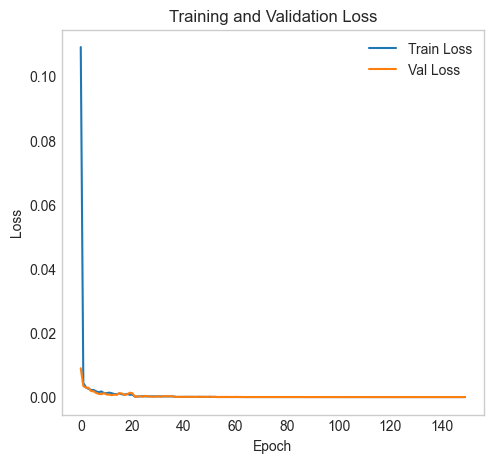

In [96]:
show_history(history, save=True, file_name="Enu-To-forces-history-26-04-2026.png", path="C:/Users/limon/OneDrive/Рабочий стол/Курсовая/my_code/graphics")

## validate $(E, \nu)$

In [97]:
model.eval()
test_loss = 0.0
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)         
        outputs = model(x_batch)
        loss = F.mse_loss(outputs, y_batch)
        test_loss += loss.item() * x_batch.size(0)

test_loss /= len(test_loader.dataset)
print(f"Test Loss: {test_loss:.4e}")

Test Loss: 1.0222e-05


In [98]:
# Пример предсказания на тестовом наборе
model.eval()
with torch.no_grad():
    # Сжатые данные
    x_sample, y_sample = next(iter(test_loader))
    output_sample = model(x_sample.to(device))
    # Восстанавливаем данные из PCA
    output_recovered = inverse_pca(output_sample.to('cpu').numpy(), pca, y_scaler)
    real_recovered = inverse_pca(y_sample.numpy(), pca, y_scaler)
    # Сравниваем предсказанные и реальные силы
    for i in range(2):
        print("Predicted PCA components:", output_sample[i])
        print("True PCA components:", y_sample[i])
        print("Predicted forces:", output_recovered[i])
        print("True forces:", real_recovered[i])
        print("\n")
    # mse, mae, r2 для восстановленных данных
    mse_test = mean_squared_error(real_recovered, output_recovered)
    mae_test = mean_absolute_error(real_recovered, output_recovered)
    r2_test = r2_score(real_recovered, output_recovered)
    avg_L1 = average_absolute_percentage_error(real_recovered, output_recovered)
    avg_L2 = average_squared_percentage_error(real_recovered, output_recovered)
    
    print("-" * 100)
    print(f"\nRecovered Test - MSE: {mse_test:.4e}, MAE: {mae_test:.4e}, R²: {r2_test:.4f}, L1: {avg_L1:.4e}, L2: {avg_L2:.4e}")


Predicted PCA components: tensor([0.2094, 0.8655], device='cuda:0')
True PCA components: tensor([0.2072, 0.8669])
Predicted forces: [-7.98665933e-08 -5.09575678e-06 -8.71953169e-06 -1.02423584e-05
 -1.03587580e-05 -9.10556026e-06 -6.02014236e-06 -3.78025954e-07]
True forces: [-7.89299899e-08 -5.09549922e-06 -8.71999530e-06 -1.02430092e-05
 -1.03594304e-05 -9.10611042e-06 -6.02021541e-06 -3.76810014e-07]


Predicted PCA components: tensor([-0.3726,  1.1491], device='cuda:0')
True PCA components: tensor([-0.3714,  1.1483])
Predicted forces: [ 1.36659417e-07 -4.98136493e-06 -8.83917543e-06 -1.04321200e-05
 -1.05549306e-05 -9.25028029e-06 -5.98922223e-06 -8.95660088e-08]
True forces: [ 1.36129811e-07 -4.98151485e-06 -8.83891231e-06 -1.04317489e-05
 -1.05545472e-05 -9.24996783e-06 -5.98918465e-06 -9.02541407e-08]


----------------------------------------------------------------------------------------------------

Recovered Test - MSE: 2.2021e-18, MAE: 8.1705e-10, R²: 1.0000, L1: 1.3055e-0

In [99]:
model(x_test_tensor.to(device).float()), y_test_tensor

(tensor([[ 0.2094,  0.8655],
         [-0.3726,  1.1491],
         [ 0.8765,  1.0355],
         ...,
         [-1.1009,  0.5910],
         [-1.4104,  0.4808],
         [ 2.7774, -0.2997]], device='cuda:0', grad_fn=<AddmmBackward0>),
 tensor([[ 0.2072,  0.8669],
         [-0.3714,  1.1483],
         [ 0.8751,  1.0400],
         ...,
         [-1.1019,  0.5903],
         [-1.4118,  0.4806],
         [ 2.7779, -0.2975]]))

# Newton method

In [100]:
def inverse_by_optimization(model, y_target, device, n_iter=1001):
    model.eval()
    
    # Инициализируем x 
    x = torch.zeros(y_target.shape[0], 8, device=device, requires_grad=True)
    
    optimizer = torch.optim.AdamW([x], lr=1)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10, min_lr=1e-8)

    for i in range(n_iter):
        optimizer.zero_grad()
        y_pred = model(x)
        mse_loss = ((y_pred - y_target) ** 2).mean()

        l2_reg = (x ** 2).mean()
        smooth_reg = ((x[:, 1:] - x[:, :-1]) ** 2).mean()
        
        loss = mse_loss + 0.001 * l2_reg + 0.0001 * smooth_reg

        loss.backward()
        torch.nn.utils.clip_grad_norm_([x], max_norm=0.5)
        optimizer.step()
        scheduler.step(loss.item())
        
        if i % 500 == 0:
            print(f"{i}: loss = {loss.item():.2e}, lr = {optimizer.param_groups[0]['lr']:.6e}")
    
    return x.detach().cpu().numpy()

# Использование
y_target = y_test_tensor.to(device)
x_found = inverse_by_optimization(model, y_target, device, n_iter=8001)

0: loss = 4.76e+00, lr = 1.000000e+00
500: loss = 2.18e-03, lr = 1.000000e-01
1000: loss = 9.78e-04, lr = 1.000000e-01
1500: loss = 6.39e-04, lr = 1.000000e-02
2000: loss = 6.03e-04, lr = 1.000000e-02
2500: loss = 5.59e-04, lr = 1.000000e-02
3000: loss = 5.12e-04, lr = 1.000000e-02
3500: loss = 4.69e-04, lr = 1.000000e-02
4000: loss = 4.30e-04, lr = 1.000000e-02
4500: loss = 3.98e-04, lr = 1.000000e-02
5000: loss = 3.72e-04, lr = 1.000000e-02
5500: loss = 3.51e-04, lr = 1.000000e-02
6000: loss = 3.35e-04, lr = 1.000000e-02
6500: loss = 3.26e-04, lr = 1.000000e-02
7000: loss = 3.24e-04, lr = 1.000000e-08
7500: loss = 3.24e-04, lr = 1.000000e-08
8000: loss = 3.24e-04, lr = 1.000000e-08


In [101]:
def mean_abs_percent_error(y_true, y_pred):
    errors = np.sum(np.abs(y_true - y_pred), axis=1) 
    true_values = np.sum(np.abs(y_true), axis=1) 
    return np.mean(errors / true_values)

def mean_squared_percent_error(y_true, y_pred):
    errors = np.sum((y_true - y_pred) ** 2, axis=1) 
    true_values = np.sum((y_true) ** 2, axis=1) 
    return np.mean((errors / true_values) ** 0.5)

def E_error(y_true, y_pred):
    E_true = y_true[:, 0::2]
    E_pred = y_pred[:, 0::2]
    return average_absolute_percentage_error(E_true, E_pred), average_squared_percentage_error(E_true, E_pred)

def nu_error(y_true, y_pred):
    nu_true = y_true[:, 1::2]
    nu_pred = y_pred[:, 1::2]
    return average_absolute_percentage_error(nu_true, nu_pred), average_squared_percentage_error(nu_true, nu_pred)

In [102]:
Y_test_pca.shape, x_found.shape

((15104, 2), (15104, 8))

In [103]:
pred = scaler.inverse_transform(x_found)
real = scaler.inverse_transform(X_test_scaled)
real_y = Y_test_pca
pred_from_pred = model(torch.tensor(x_found, dtype=torch.float32).to(device)).detach().cpu().numpy()
pred_from_real = model(torch.tensor(X_test_scaled, dtype=torch.float32).to(device)).detach().cpu().numpy()

pfp_unscaled_pca = pca.inverse_transform(pred_from_pred)
pfr_unscaled_pca = pca.inverse_transform(pred_from_real)

pfp_unscaled = y_scaler.inverse_transform(pfp_unscaled_pca)
pfr_unscaled = y_scaler.inverse_transform(pfr_unscaled_pca)

pfp_unscaled.shape, pfr_unscaled.shape, real.shape, Y_test.shape

((15104, 8), (15104, 8), (15104, 8), (15104, 8))

In [104]:
print(f"orig to pred_from_real: {average_absolute_percentage_error(real_y, pred_from_real)}")
print(f"orig to pred_from_pred: {average_absolute_percentage_error(real_y, pred_from_pred)}")
print(f"pred_from_real to pred_from_pred: {average_absolute_percentage_error(pred_from_real, pred_from_pred)}")

print(f"orig to pred_from_real: {mean_squared_percent_error(real_y, pred_from_real)}")
print(f"orig to pred_from_pred: {mean_squared_percent_error(real_y, pred_from_pred)}")
print(f"pred_from_real to pred_from_pred: {mean_squared_percent_error(pred_from_real, pred_from_pred)}")

orig to pred_from_real: 0.001295348459878245
orig to pred_from_pred: 0.001023633209591002
pred_from_real to pred_from_pred: 0.0018522626487538218
orig to pred_from_real: 0.0016774658343753728
orig to pred_from_pred: 0.0013654228491366926
pred_from_real to pred_from_pred: 0.0024377473164349794


In [105]:
#print(f"orig to pred_from_real: {average_absolute_percentage_error(Y_test, pfr_unscaled)}")
#print(f"orig to pred_from_pred: {average_absolute_percentage_error(Y_test, pfp_unscaled)}")
#print(f"pred_from_real to pred_from_pred: {average_absolute_percentage_error(pfr_unscaled, pfp_unscaled)}")

#print(f"orig to pred_from_real: {mean_squared_percent_error(Y_test, pfr_unscaled)}")
#print(f"orig to pred_from_pred: {mean_squared_percent_error(Y_test, pfp_unscaled)}")
#print(f"pred_from_real to pred_from_pred: {mean_squared_percent_error(pfr_unscaled, pfp_unscaled)}")

In [106]:
("E=", E_error(real, pred)), ("nu=", nu_error(real, pred))

(('E=', (np.float64(0.23472643751991404), np.float64(0.3053054723772681))),
 ('nu=', (np.float64(0.1774992913598099), np.float64(0.21440411528975065))))

# Try **Gradient Invertion**

In [ ]:
import torch
import torch.nn as nn
import numpy as np

def find_X_for_target_Y_gradient_batch(model, Y_target_batch, x_scaler, y_scaler, pca, 
                                       device='cpu', lr=0.01, n_steps=3000, 
                                       x_init=None, verbose=True):
    model.eval()
    
    # 1. Приводим весь батч в пространство модели
    Y_target_batch = np.atleast_2d(Y_target_batch)
    Y_target_scaled = y_scaler.transform(Y_target_batch)
    Y_target_pca = pca.transform(Y_target_scaled)
    y_target_t = torch.tensor(Y_target_pca, dtype=torch.float32, device=device)
    
    n_samples = Y_target_batch.shape[0]
    input_dim = model.model[0].in_features
    
    # 2. Инициализация оптимизируемого входа (батч)
    if x_init is None:
        x_opt = torch.randn(n_samples, input_dim, device=device, requires_grad=True)
    else:
        x_init = np.atleast_2d(x_init)
        if x_init.shape[0] != n_samples:
            raise ValueError("x_init должен содержать столько же образцов, сколько Y_target_batch")
        x_init_scaled = x_scaler.transform(x_init)
        x_opt = torch.tensor(x_init_scaled, dtype=torch.float32, device=device, requires_grad=True)
        
    optimizer = torch.optim.Adam([x_opt], lr=lr)
    criterion = nn.MSELoss(reduction='mean')
    
    best_loss = float('inf')
    best_x_scaled = None
    
    # 3. Оптимизация всего батча одновременно
    for step in range(n_steps):
        optimizer.zero_grad()
        pred_pca = model(x_opt)
        loss = criterion(pred_pca, y_target_t)
        # L2-регуляризация для стабильности
        loss += 1e-5 * torch.sum(x_opt**2)
        
        loss.backward()
        optimizer.step()
        
        if loss.item() < best_loss:
            best_loss = loss.item()
            best_x_scaled = x_opt.detach().clone()
            
        if verbose and step % 500 == 0:
            print(f"Step {step:4d} | Batch Loss: {loss.item():.4e}")
            
    # 4. Возврат к физическим величинам
    X_opt_phys = x_scaler.inverse_transform(best_x_scaled.cpu().numpy())
    return X_opt_phys, best_loss

In [ ]:
# Запуск пакетной инверсии
X_found_all, final_loss = find_X_for_target_Y_gradient_batch(
    model=model, 
    Y_target_batch=Y_test, 
    x_scaler=x_scaler, 
    y_scaler=y_scaler, 
    pca=pca,
    device=device,
    lr=0.01, 
    n_steps=5000, 
    verbose=True
)

print("\nИнверсия завершена. Вычисление метрик...")

eps = 1e-12
mae_x = mean_absolute_error(X_test, X_found_all)
mse_x = mean_squared_error(X_test, X_found_all)
rmse_x = np.sqrt(mse_x)

rel_err = np.abs((X_test - X_found_all) / (np.abs(X_test) + eps))
mape_x = np.mean(rel_err) * 100
max_rel = np.max(rel_err) * 100

# Раздельно по E и nu
E_real, nu_real = X_test[:, 0::2], X_test[:, 1::2]
E_found, nu_found = X_found_all[:, 0::2], X_found_all[:, 1::2]

rel_E = np.abs((E_real - E_found) / (np.abs(E_real) + eps))
rel_nu = np.abs((nu_real - nu_found) / (np.abs(nu_real) + eps))

mape_E = np.mean(rel_E) * 100
mape_nu = np.mean(rel_nu) * 100

# Проверка согласованности Y (пакетно)
X_found_scaled = x_scaler.transform(X_found_all)
with torch.no_grad():
    Y_pred_pca = model(torch.tensor(X_found_scaled, dtype=torch.float32, device=device))
Y_pred_phys = inverse_pca(Y_pred_pca.cpu().numpy(), pca, y_scaler)
y_mape = np.mean(np.abs((Y_test - Y_pred_phys) / (np.abs(Y_test) + eps))) * 100

# Вывод итогов
print("\n" + "="*65)
print("ИТОГОВАЯ СТАТИСТИКА ВОССТАНОВЛЕНИЯ X (ПАКЕТНАЯ ИНВЕРСИЯ)")
print("="*65)
print(f"{'MAE (весь X)':<35} | {mae_x:.4e}")
print(f"{'RMSE':<35} | {rmse_x:.4e}")
print(f"{'MAPE (средняя отн. ошибка, %)'}: {mape_x:.2f}%")
print(f"{'MAX отн. ошибка (%)':<35} | {max_rel:.2f}%")
print("-" * 65)
print(f"{'E (Модуль упругости) MAPE (%)':<35} | {mape_E:.2f}%")
print(f"{'nu (Коэфф. Пуассона) MAPE (%)':<35} | {mape_nu:.2f}%")
print(f"{'Согласованность Y MAPE (%)':<35} | {y_mape:.2f}%")
print("="*65)


Step    0 | Batch Loss: 1.0462e+01
Step  500 | Batch Loss: 4.2379e-01
Step 1000 | Batch Loss: 3.3572e-01
Step 1500 | Batch Loss: 3.1124e-01
Step 2000 | Batch Loss: 3.0161e-01
Step 2500 | Batch Loss: 2.9669e-01
Step 3000 | Batch Loss: 2.9402e-01
Step 3500 | Batch Loss: 2.9240e-01
Step 4000 | Batch Loss: 2.9117e-01
Step 4500 | Batch Loss: 2.9048e-01

Инверсия завершена. Вычисление метрик...

ИТОГОВАЯ СТАТИСТИКА ВОССТАНОВЛЕНИЯ X (ПАКЕТНАЯ ИНВЕРСИЯ)
MAE (весь X)                        | 2.4396e-01
RMSE                                | 3.9217e-01
MAPE (средняя отн. ошибка, %): 27.32%
MAX отн. ошибка (%)                 | 401.75%
-----------------------------------------------------------------
E (Модуль упругости) MAPE (%)       | 35.42%
nu (Коэфф. Пуассона) MAPE (%)       | 19.22%
Согласованность Y MAPE (%)          | 436712.81%


## **Grad Inversion ensemble**

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error, r2_score

def ensemble_gradient_inversion(model, 
                                Y_target_batch, 
                                x_scaler, 
                                y_scaler, 
                                pca, 
                                n_members=10, 
                                device='cpu', 
                                verbose=True):
    model.eval()
    Y_target_scaled = y_scaler.transform(np.atleast_2d(Y_target_batch))
    Y_target_pca = pca.transform(Y_target_scaled)
    y_target_t = torch.tensor(Y_target_pca, dtype=torch.float32, device=device)
    n_samples, input_dim = Y_target_pca.shape[0], model.model[0].in_features
    
    X_candidates = []
    losses = []
    criterion = nn.MSELoss(reduction='mean')
    
    for m in range(n_members):
        torch.manual_seed(m)
        np.random.seed(m)
        
        # Разнообразие инициализации
        if m % 3 == 0:
            x_init = torch.randn(n_samples, input_dim, device=device)
        elif m % 3 == 1:
            x_init = torch.empty(n_samples, input_dim, device=device).uniform_(-2.0, 2.0)
        else:
            x_init = torch.zeros(n_samples, input_dim, device=device) + torch.randn(n_samples, input_dim, device=device) * 0.5
            
        lr_candidates = [0.005, 0.01, 0.02, 0.05]
        lr = lr_candidates[m % len(lr_candidates)]
        
        x_opt = x_init.requires_grad_(True)
        optimizer = torch.optim.Adam([x_opt], lr=lr)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=1500, eta_min=1e-4)
        
        best_loss, best_x = float('inf'), None
        patience, wait = 300, 0
        
        for _ in range(4000):
            optimizer.zero_grad()
            pred_pca = model(x_opt)
            loss = criterion(pred_pca, y_target_t)
            
            E, nu = x_opt[:, 0::2], x_opt[:, 1::2]
            loss += 1e-2 * (torch.mean(torch.relu(-E)**2) + torch.mean(torch.relu(nu - 0.5)**2))
            
            loss.backward()
            optimizer.step()
            scheduler.step()
            
            if loss.item() < best_loss:
                best_loss = loss.item()
                best_x = x_opt.detach().clone()
                wait = 0
            else:
                wait += 1
            if wait > patience:
                break
                
        X_phys = x_scaler.inverse_transform(best_x.cpu().numpy())
        X_phys[:, 0::2] = np.clip(X_phys[:, 0::2], 0.01, None)
        X_phys[:, 1::2] = np.clip(X_phys[:, 1::2], 0.0, 0.49)
        
        X_candidates.append(X_phys)
        losses.append(best_loss)
        if verbose and (m + 1) % 3 == 0:
            print(f"Ensemble member {m+1}/{n_members} | Loss: {best_loss:.4e}")
            
    X_candidates = np.array(X_candidates)
    losses = np.array(losses)
    
    # Взвешивание по потерям
    weights = 1.0 / (losses + 1e-8)
    weights /= weights.sum()
    
    X_mean = np.average(X_candidates, axis=0, weights=weights)
    X_median = np.median(X_candidates, axis=0)
    X_std = np.std(X_candidates, axis=0)
    X_best = X_candidates[np.argmin(losses)]
    
    return X_mean, X_median, X_best, X_std, losses, weights

In [ ]:
# Запуск ансамбля на всём Y_test
X_mean, X_median, X_best, X_std, losses, weights = ensemble_gradient_inversion(
    model=model,
    Y_target_batch=Y_test,
    x_scaler=x_scaler,
    y_scaler=y_scaler,
    pca=pca,
    n_members=15,
    device=device,
    verbose=True
)

# Выбор стратегии агрегации
X_found_all = X_median  

print("\nРасчёт метрик...")
eps = 1e-12
rel_err = np.abs((X_test - X_found_all) / (np.abs(X_test) + eps))

def stat_print(name, arr):
    print(f"{name:<35} | Mean: {np.mean(arr):.4f} | Med: {np.median(arr):.4f} | "
          f"P90: {np.percentile(arr, 90):.4f} | Std: {np.std(arr):.4f}")

print("\n" + "="*75)
print("СТАТИСТИКА ВОССТАНОВЛЕНИЯ X (АНСАМБЛЬ)")
print("="*75)
stat_print("MAPE X (%)", np.mean(rel_err, axis=1)*100)
stat_print("RMSE X", np.sqrt(mean_squared_error(X_test, X_found_all, multioutput='raw_values')))

for i in range(X_test.shape[1]):
    name = f"E{i//2}" if i%2==0 else f"nu{i//2}"
    r2 = r2_score(X_test[:, i], X_found_all[:, i])
    print(f"R2 {name:<12} = {r2:.4f}")

# Оценка неопределённости (стандартное отклонение ансамбля)
print("\nНеопределённость восстановления (std ансамбля):")
for i in range(X_test.shape[1]):
    name = f"E{i//2}" if i%2==0 else f"nu{i//2}"
    print(f"  Std {name:<6} = {np.mean(X_std[:, i]):.4e}")

# Проверка согласованности Y
X_found_scaled = x_scaler.transform(X_found_all)
with torch.no_grad():
    Y_pred_pca = model(torch.tensor(X_found_scaled, dtype=torch.float32, device=device))
Y_pred_phys = inverse_pca(Y_pred_pca.cpu().numpy(), pca, y_scaler)
y_mape = np.mean(np.abs((Y_test - Y_pred_phys) / (np.abs(Y_test) + eps))) * 100
print(f"\nСогласованность Y MAPE (%) : {y_mape:.2f}%")
print("="*75)


Ensemble member 3/15 | Loss: 2.1937e-03
Ensemble member 6/15 | Loss: 2.6739e-03
Ensemble member 9/15 | Loss: 3.3607e-03
Ensemble member 12/15 | Loss: 1.7250e-03
Ensemble member 15/15 | Loss: 2.2045e-03

Расчёт метрик...

СТАТИСТИКА ВОССТАНОВЛЕНИЯ X (АНСАМБЛЬ)
MAPE X (%)                          | Mean: 25.4398 | Med: 24.4484 | P90: 37.8718 | Std: 9.2566
RMSE X                              | Mean: 0.2548 | Med: 0.1147 | P90: 0.5327 | Std: 0.2002
R2 E0           = 0.1412
R2 nu0          = -0.8375
R2 E1           = 0.3425
R2 nu1          = -1.0090
R2 E2           = 0.5502
R2 nu2          = -1.0279
R2 E3           = 0.9569
R2 nu3          = -0.8019

Неопределённость восстановления (std ансамбля):
  Std E0     = 4.4107e-01
  Std nu0    = 6.4824e-02
  Std E1     = 3.9079e-01
  Std nu1    = 7.5963e-02
  Std E2     = 3.1522e-01
  Std nu2    = 7.0051e-02
  Std E3     = 1.4261e-01
  Std nu3    = 7.8858e-02

Согласованность Y MAPE (%) : 11676.10%


# InvNN

## Архитектура

In [113]:
class EnuToForces(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(EnuToForces, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        x = self.model(x)
        return x

In [114]:
class InverseLayers(nn.Module):

    def __init__(self, input_dim, output_dim, hidden_dims=[64, 128, 64], activation=nn.GELU, bn_momentum=0.1, norm_layers=False):
        super(InverseLayers, self).__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            if norm_layers:
                layers.append(nn.BatchNorm1d(h_dim, momentum=bn_momentum, eps=1e-5))
            layers.append(activation()) 
            prev_dim = h_dim
        Last_layer = nn.Linear(prev_dim, output_dim)
        # Инициализация в ноль: на старте s=0, t=0 => exp(s)=1 => v=u
        nn.init.zeros_(Last_layer.weight)
        nn.init.zeros_(Last_layer.bias)
        layers.append(Last_layer)        
        self.net = nn.Sequential(*layers)


    def forward(self, x):
        return self.net(x)

In [115]:
# Обратимая нейросеть для преобразования между Enu и Forces
class INNwithPCA(nn.Module):
    def __init__(self, 
                 inp1_dim=5, 
                 inp2_dim=3, 
                 layer_s1_dims=[32, 16], 
                 layer_s2_dims=[32, 16], 
                 layer_t1_dims=[32, 16], 
                 layer_t2_dims=[32, 16], 
                 s1_activation=nn.ReLU,
                 s2_activation=nn.ReLU,
                 t1_activation=nn.ReLU,
                 t2_activation=nn.ReLU,
                 clamp = 1,
                 bn_momentum=0.1,
                 norm_layers=False
                 ):
        super(INNwithPCA, self).__init__()
        #self.clamp_range = clamp_range
        self.inp1_dim = inp1_dim
        self.inp2_dim = inp2_dim
        self.clamp = clamp

        self.s1 = InverseLayers(input_dim=inp2_dim, output_dim=inp1_dim, hidden_dims=layer_s1_dims, activation=s1_activation, bn_momentum=bn_momentum, norm_layers=norm_layers)
        self.t1 = InverseLayers(input_dim=inp2_dim, output_dim=inp1_dim, hidden_dims=layer_t1_dims, activation=t1_activation, bn_momentum=bn_momentum, norm_layers=norm_layers)

        self.s2 = InverseLayers(input_dim=inp1_dim, output_dim=inp2_dim, hidden_dims=layer_s2_dims, activation=s2_activation, bn_momentum=bn_momentum, norm_layers=norm_layers)
        self.t2 = InverseLayers(input_dim=inp1_dim, output_dim=inp2_dim, hidden_dims=layer_t2_dims, activation=t2_activation, bn_momentum=bn_momentum, norm_layers=norm_layers)


    def _clamp(self, x):
        return torch.clamp(x, min=self.clamp_range[0], max=self.clamp_range[1])

    def forward(self, x, inverse=False):
        if not inverse:
            u1 = x[:, :self.inp1_dim] # real y
            u2 = x[:, self.inp1_dim:] # latent z

            #s1 = self._clamp(self.s1(u2))
            s1 = self.clamp * torch.tanh(self.s1(u2))
            t1 = self.t1(u2)
            v1 = u1 * torch.exp(s1) + t1
            
            #s2 = self._clamp(self.s2(v1))
            s2 = self.clamp * torch.tanh(self.s2(v1))
            t2 = self.t2(v1)
            v2 = u2 * torch.exp(s2) + t2
            
            logJ = s1.sum(dim=1) + s2.sum(dim=1)
            return torch.cat([v1, v2], dim=1), logJ
        else:
            v1 = x[:, :self.inp1_dim]
            v2 = x[:, self.inp1_dim:]
            
            s2 = self.clamp * torch.tanh(self.s2(v1))
            #s2 = self._clamp(self.s2(v1))
            t2 = self.t2(v1)
            u2 = (v2 - t2) * torch.exp(-s2)
            
            s1 = self.clamp * torch.tanh(self.s1(u2))
            #s1 = self._clamp(self.s1(u2))
            t1 = self.t1(u2)
            u1 = (v1 - t1) * torch.exp(-s1)
            
            return torch.cat([u1, u2], dim=1), None

        

In [116]:
# Архитектура многослойной обратимой сети
class MultiInvertibleANN(nn.Module):
    def __init__(
            self, 
            inp1_dim=5, 
            inp2_dim=3, 
            layer_s1_dims=[32, 16], 
            layer_s2_dims=[32, 16], 
            layer_t1_dims=[32, 16], 
            layer_t2_dims=[32, 16], 
            s1_activation=nn.ReLU,
            s2_activation=nn.ReLU,
            t1_activation=nn.ReLU,
            t2_activation=nn.ReLU,
            clamp = 1,
            bn_momentum=0.1,
            inv_layers=3,
            norm_layers=False
            ):
        
        self.perm_indices = [torch.randperm(inp1_dim + inp2_dim) for _ in range(inv_layers)]
        self.inv_perm_indices = [torch.argsort(p) for p in self.perm_indices]

        # Слои
        super(MultiInvertibleANN, self).__init__()
        self.inp1_dim = inp1_dim
        self.inp2_dim = inp2_dim
        self.layers = nn.ModuleList()
        for _ in range(inv_layers):
            self.layers.append(INNwithPCA(
                inp1_dim=inp1_dim, 
                inp2_dim=inp2_dim, 
                layer_s1_dims=layer_s1_dims, 
                layer_s2_dims=layer_s2_dims, 
                layer_t1_dims=layer_t1_dims, 
                layer_t2_dims=layer_t2_dims, 
                s1_activation=s1_activation,
                s2_activation=s2_activation,
                t1_activation=t1_activation,
                t2_activation=t2_activation,
                clamp=clamp,
                bn_momentum=bn_momentum,
                norm_layers=norm_layers
            ))
            
    def _permute(self, x, layer_idx):
        """Прямая перестановка для слоя layer_idx"""
        perm = self.perm_indices[layer_idx]
        #.to(x.device) 
        return x[:, perm]
    
    def _permute_inv(self, x, layer_idx):
        """Обратная перестановка для слоя layer_idx"""
        inv_perm = self.inv_perm_indices[layer_idx]
        #.to(x.device)
        return x[:, inv_perm]

    def forward(self, x, inverse=False):
        if not inverse:
            logJ = 0.0
            for idx, layer in enumerate(self.layers):
                x, logj = layer(x, inverse=False)
                x = self._permute(x, idx).to(x.device) 
                logJ += logj
        else:
            logJ = None
            for idx in reversed(range(len(self.layers))):
                x = self._permute_inv(x, idx).to(x.device)
                x, _ = self.layers[idx](x, inverse=True)
        return x, logJ

## Train 

In [136]:
def concat_y_with_sampled_z(Y, z_dim, device, coef=1.0):
    batch_size = Y.shape[0]
    Z_sample = torch.randn(batch_size, z_dim, device=device) * coef
    return torch.cat([Y, Z_sample], dim=1)


def concat_y_with_zeros(Y, z_dim, device):
    batch_size = Y.shape[0]
    Z_sample = torch.zeros(batch_size, z_dim, device=device)
    return torch.cat([Y, Z_sample], dim=1)


def mean_abs_percent_error(y_true, y_pred):
    errors = np.sum(np.abs(y_true - y_pred), axis=1) 
    true_values = np.sum(np.abs(y_true), axis=1) 
    return np.mean(errors / true_values)


def mean_squared_percent_error(y_true, y_pred):
    errors = np.sum((y_true - y_pred) ** 2, axis=1) 
    true_values = np.sum((y_true) ** 2, axis=1) 
    return np.mean((errors / true_values) ** 0.5)


def count_metrics(model_inn_pca, 
                  input_test_scaleded, 
                  output_test_scaleded,
                  inverse=False, 
                  device=torch.device("cpu"),
                  is_pca=False,
                  pca=None,
                  scaler=None):
    model_inn_pca.eval()

    if inverse:
        input_test_scaleded = concat_y_with_zeros(torch.tensor(input_test_scaleded, dtype=torch.float32).to(device), z_dim=4, device=device)

    pred, _= model_inn_pca(torch.tensor(input_test_scaleded, dtype=torch.float32).to(device), inverse=inverse)

    if is_pca:
        pred = pred.detach().cpu().numpy()[:, :4]
        pred =  pca.inverse_transform(pred)
        output_test_scaleded =  pca.inverse_transform(output_test_scaleded)

    else:
        pred = pred.detach().cpu().numpy()

    pred_unscalled = scaler.inverse_transform(pred)
    true_unscalled = scaler.inverse_transform(output_test_scaleded)
    
    mape = mean_abs_percent_error(true_unscalled, pred_unscalled)
    mspe = mean_squared_percent_error(true_unscalled, pred_unscalled)
    
    print(f"MAPE: {mape}")
    print(f"MSPE: {mspe}")
    
    return mape, mspe


In [137]:
def loss_for_INN(inn, X, Y, 
                # lambda_y=1.0, 
                # lambda_z=1.0, 
                # lambda_J=1.0, 
                # lambda_x=0.2,
                 use_sampled_z=True):
    device = X.device
    
    # 1. Прямой проход: X -> [Y_pred, Z]
    y_pred_full, logJ = inn(X, inverse=False)
    Y_pred = y_pred_full[:, :inn.inp1_dim]
    Z_fwd  = y_pred_full[:, inn.inp1_dim:]
    
    # 2 Прямой loss]
    y_loss = F.mse_loss(Y_pred, Y) 
    #* lambda_y
    
    # 3. Latent loss 
    z_loss = 0.5 * torch.mean(Z_fwd**2) 
    #* lambda_z
    
    # 4 ОМП
    J_loss = -torch.mean(logJ) 
    #* lambda_J
    
    # 5. обратный loss
    if use_sampled_z:
        YZ_inv = concat_y_with_sampled_z(Y, inn.inp2_dim, device)
    else:
        YZ_inv = y_pred_full
        
    X_rec, _ = inn(YZ_inv, inverse=True)
    x_loss = F.mse_loss(X_rec, X) 
    #* lambda_x

    # 6 Обратный лосс при z = 0
    YZ_zero = concat_y_with_zeros(Y, inn.inp2_dim, device)
    X_zero_rec, _ = inn(YZ_zero, inverse=True)
    zero_loss = F.mse_loss(X_zero_rec, X) 
    #* lambda_x

    return y_loss, z_loss, J_loss, x_loss, zero_loss

In [138]:

def train_inn(model, 
              train_loader, 
              val_loader, 
              optimizer, 
              scheduler=None, 
              history={
                'train_loss': [], 
                'val_loss': [], 
                'train_x_loss': [],
                'val_x_loss': [],
                'train_y_loss': [], 
                'val_y_loss': [], 
                'train_z_loss': [], 
                'val_z_loss': [], 
                'train_J_loss': [], 
                'val_J_loss': [],
                'train_zero_loss': [],
                'val_zero_loss': []
                }, 
              num_epochs=10, 
              device='cuda',
              lambda_y=1.0, 
              lambda_z=1.0,
              lambda_J=0.5,
              lambda_x=0.5,
              clip_grad_norm=1.0):
    
    model.to(device)
    
    for epoch in range(num_epochs):
        model.train()
        train_loss, loss_x, loss_y, loss_z, loss_J, loss_zero = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
        #pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        
        for X_batch, Y_batch in train_loader:
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            optimizer.zero_grad()
            
            y_loss, z_loss, J_loss, x_loss, zero_loss = loss_for_INN(
                model, 
                X_batch, 
                Y_batch, 
                #lambda_y, 
                #lambda_z, 
                #lambda_J, 
                #lambda_x, 
                use_sampled_z=True)
            loss = y_loss * lambda_y + z_loss * lambda_z + J_loss * lambda_J + x_loss * lambda_x   
            loss_x += x_loss.item() * X_batch.size(0)
            loss_y += y_loss.item() * X_batch.size(0)
            loss_z += z_loss.item() * X_batch.size(0)
            loss_J += J_loss.item() * X_batch.size(0) 
            loss_zero += zero_loss.item() * X_batch.size(0)
            train_loss += loss.item() * X_batch.size(0)


            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)
            optimizer.step()
            
            #pbar.set_postfix({'loss': f'{loss.item():.4f}'})
            
        avg_train = train_loss / len(train_loader.dataset)
        avg_x_train = loss_x / len(train_loader.dataset)
        avg_y_train = loss_y / len(train_loader.dataset)
        avg_z_train = loss_z / len(train_loader.dataset)
        avg_J_train = loss_J / len(train_loader.dataset)
        avg_zero_train = loss_zero / len(train_loader.dataset)

        history['train_loss'].append(avg_train)
        history['train_x_loss'].append(avg_x_train)
        history['train_y_loss'].append(avg_y_train)
        history['train_z_loss'].append(avg_z_train)
        history['train_J_loss'].append(avg_J_train)
        history['train_zero_loss'].append(avg_zero_train)
        # ---------------- ВАЛИДАЦИЯ ----------------
        model.eval()
        val_loss, val_y_loss, val_z_loss, val_J_loss, val_x_loss, val_zero_loss = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
        with torch.no_grad():
            for X_val, Y_val in val_loader:
                X_val, Y_val = X_val.to(device), Y_val.to(device)
                y_loss, z_loss, J_loss, x_loss, zero_loss = loss_for_INN(
                    model, 
                    X_val, 
                    Y_val,
                                        # lambda_y, lambda_z, lambda_J, lambda_x,
                    use_sampled_z=True
                )
                val_y_loss += y_loss.item() * X_val.size(0)
                val_z_loss += z_loss.item() * X_val.size(0)
                val_J_loss += J_loss.item() * X_val.size(0)
                val_x_loss += x_loss.item() * X_val.size(0)
                val_zero_loss += zero_loss.item() * X_val.size(0)
                val_loss += (y_loss * lambda_y + z_loss * lambda_z + J_loss * lambda_J + x_loss * lambda_x).item() * X_val.size(0)

        avg_val = val_loss / len(val_loader.dataset)
        avg_x_val = val_x_loss / len(val_loader.dataset)
        avg_y_val = val_y_loss / len(val_loader.dataset)
        avg_z_val = val_z_loss / len(val_loader.dataset)
        avg_J_val = val_J_loss / len(val_loader.dataset)
        avg_zero_val = val_zero_loss / len(val_loader.dataset)

        history['val_loss'].append(avg_val)
        history['val_x_loss'].append(avg_x_val)
        history['val_y_loss'].append(avg_y_val)
        history['val_z_loss'].append(avg_z_val)
        history['val_J_loss'].append(avg_J_val)
        history['val_zero_loss'].append(avg_zero_val)

        if epoch == 0 or (epoch + 1) % 5 == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch+1} | Train: {avg_train:.2e} | Val: {avg_val:.2e}", end=" | ")
            print(f"Epoch {epoch+1} | Train_x: {avg_x_train:.2e} | Val_x: {avg_x_val:.2e}", end=" | ")
            print(f"Epoch {epoch+1} | Train_y: {avg_y_train:.2e} | Val_y: {avg_y_val:.2e}", end=" | ")
            print(f"Epoch {epoch+1} | Train_z: {avg_z_train:.2e} | Val_z: {avg_z_val:.2e}", end=" | ")
            print(f"Epoch {epoch+1} | Train_J: {avg_J_train:.2e} | Val_J: {avg_J_val:.2e}", end=" | ")
            print(f"Epoch {epoch+1} | Train_zero: {avg_zero_train:.2e} | Val_zero: {avg_zero_val:.2e}", end=" | ")
            print(f"LR: {optimizer.param_groups[0]['lr']:.2e}")
        
        # шаг шейдера 
        if scheduler is not None:
            scheduler.step()
            
        if len(history['val_loss']) > 1 and avg_val == min(history['val_loss']):
            torch.save(model.state_dict(), "best_inn.pth")
            
    plt.figure(figsize=(8,5))
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['val_loss'], label='Val')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid()
    plt.show()
    
    return model, history



In [139]:
import torch
from torch.optim import lr_scheduler
def train_pipeline_with_res(
        X_test_scaled,
        Y_test_pca,
        model_inn_pca,
        train_loader,
        val_loader,
        pca,
        x_scaler,
        y_scaler,
        num_epochs=25,
        device=torch.device("cpu"),
        learnung_rate=1e-3, 
        eta_min=1e-5,
        lambda_y=1.0, 
        lambda_z=1e-4, 
        lambda_J=1e-4, 
        lambda_x=1e-4,
        clip_grad_norm=1.0,
        history = {}
    ):

    # Обучение ТОЛЬКО прямой сети
    optimizer = torch.optim.Adam(model_inn_pca.parameters(), lr=learnung_rate)
    scheduler = lr_scheduler.CosineAnnealingLR(
        optimizer, 
        T_max=num_epochs,   
        eta_min=eta_min      
    )

    model_inn_pca, history = train_inn(
        model_inn_pca, 
        train_loader, 
        val_loader, 
        optimizer=optimizer,
        scheduler=scheduler, 
        num_epochs=num_epochs, 
        device=device,
        lambda_y=lambda_y, 
        lambda_z=lambda_z, 
        lambda_J=lambda_J, 
        lambda_x=lambda_x,
        clip_grad_norm=clip_grad_norm,
        history=history
    )

    # Временный результат
    print("TMP RES")
    print("FWD")
    mape_fwd, mspe_fwd = count_metrics(  
        model_inn_pca, 
        X_test_scaled, 
        Y_test_pca,
        inverse=False, 
        device=device,
        is_pca=True,
        pca=pca,
        scaler=y_scaler)


    print("BWD")
    mape_bwd, mspe_bwd = count_metrics(
        model_inn_pca, 
        Y_test_pca, 
        X_test_scaled,
        inverse=True, 
        device=device,
        is_pca=False,
        pca=None,
        scaler=x_scaler)
    return model_inn_pca, history, mape_fwd, mspe_fwd, mape_bwd, mspe_bwd

## Pipeline

In [145]:
model_inn_pca = MultiInvertibleANN(
    inp1_dim=4, 
    inp2_dim=4, 
    layer_s1_dims=[64, 32], 
    layer_s2_dims=[64, 32], 
    layer_t1_dims=[64, 64, 32], 
    layer_t2_dims=[64, 128, 64, 32], 
    s1_activation=nn.GELU,
    s2_activation=nn.GELU,
    t1_activation=nn.GELU,
    t2_activation=nn.GELU,
    clamp=2, 
    inv_layers=6,
    )

multi_hist ={
    'train_loss': [], 
    'val_loss': [], 
    'train_x_loss': [],
    'val_x_loss': [],
    'train_y_loss': [], 
    'val_y_loss': [], 
    'train_z_loss': [], 
    'val_z_loss': [], 
    'train_J_loss': [], 
    'val_J_loss': [],
    'train_zero_loss': [],
    'val_zero_loss': []
    }

In [146]:
multi_hist

{'train_loss': [],
 'val_loss': [],
 'train_x_loss': [],
 'val_x_loss': [],
 'train_y_loss': [],
 'val_y_loss': [],
 'train_z_loss': [],
 'val_z_loss': [],
 'train_J_loss': [],
 'val_J_loss': [],
 'train_zero_loss': [],
 'val_zero_loss': []}

In [147]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Go to 1 / 1 iteration with lambdas:  {'lambda_y': 1.0, 'lambda_z': 0.0005, 'lambda_J': 0.0005, 'lambda_x': 0.0001}
Epoch 1 | Train: 1.52e-01 | Val: 1.13e-02 | Epoch 1 | Train_x: 1.55e+01 | Val_x: 3.98e+00 | Epoch 1 | Train_y: 1.44e-01 | Val_y: 6.53e-03 | Epoch 1 | Train_z: 6.21e+00 | Val_z: 1.63e+00 | Epoch 1 | Train_J: 7.74e+00 | Val_J: 7.08e+00 | Epoch 1 | Train_zero: 9.31e+00 | Val_zero: 3.15e+00 | LR: 1.00e-03
Epoch 5 | Train: 6.05e-03 | Val: 6.38e-03 | Epoch 5 | Train_x: 1.20e+00 | Val_x: 1.29e+00 | Epoch 5 | Train_y: 2.98e-03 | Val_y: 3.28e-03 | Epoch 5 | Train_z: 1.88e+00 | Val_z: 1.99e+00 | Epoch 5 | Train_J: 4.03e+00 | Val_J: 3.95e+00 | Epoch 5 | Train_zero: 1.01e+00 | Val_zero: 1.09e+00 | LR: 1.00e-03
Epoch 10 | Train: 4.76e-03 | Val: 4.48e-03 | Epoch 10 | Train_x: 1.06e+00 | Val_x: 1.07e+00 | Epoch 10 | Train_y: 1.80e-03 | Val_y: 1.51e-03 | Epoch 10 | Train_z: 1.96e+00 | Val_z: 1.93e+00 | Epoch 10 | Train_J: 3.75e+00 | Val_J: 3.81e+00 | Epoch 10 | Train_zero: 9.05e-01 | Val_

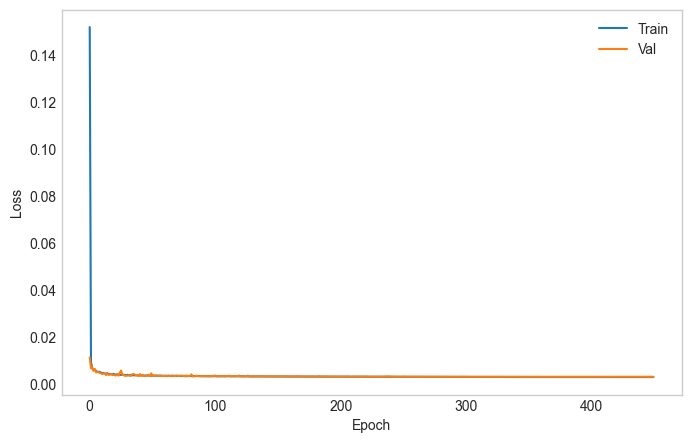

TMP RES
FWD
MAPE: 0.0014166389987363514
MSPE: 0.0014680442359425883
BWD
MAPE: 0.18656821463203488
MSPE: 0.2260978219608003





C:\Users\limon\AppData\Local\Temp\ipykernel_29328\1993485282.py:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pred, _= model_inn_pca(torch.tensor(input_test_scaleded, dtype=torch.float32).to(device), inverse=inverse)


In [148]:
lambdas = {"lambda_y": [1.0 - 0.05*i for i in range(5)], 
           "lambda_z": [5e-4 * (4**i) for i in range(5)], 
           "lambda_J": [5e-4 * (4**i) for i in range(5)], 
           "lambda_x": [1e-4 * (2**(i ** 2)) for i in range(5)]}

total_its = 1
for i in range(total_its):
    print(f"Go to {i+1} / {total_its} iteration with lambdas: ", {k: v[i] for k, v in lambdas.items()})
    out= train_pipeline_with_res(
        X_test_scaled,
        Y_test_pca,
        model_inn_pca,
        train_loader,
        val_loader,
        pca,
        x_scaler,
        y_scaler,
        history=multi_hist,
        num_epochs=450,
        device=device,
        learnung_rate=1e-3 * (0.1 ** i) , 
        eta_min=1e-7 * (0.1 ** i),
        lambda_y=lambdas["lambda_y"][i],
        lambda_z=lambdas["lambda_z"][i],
        lambda_J=lambdas["lambda_J"][i],
        lambda_x=lambdas["lambda_x"][i],
        clip_grad_norm=1.0,
    )
    model_inn_pca = out[0]
    multi_hist = out[1]
    _ = out[2]
    print("\n" + "="*150 + "\n" + "="*150 + "\n" + "\n")

In [160]:
torch.save(model_inn_pca.state_dict(), 'model_inn_pca.pth')

In [ ]:
import json

def to_serializable(obj):
    if isinstance(obj, dict):
        return {k: to_serializable(v) for k, v in obj.items()}
    return obj

with open('multi_hist_pca.json', 'w', encoding='utf-8') as f:
    json.dump(to_serializable(multi_hist), f, indent=2, ensure_ascii=False)

#with open('history.json', 'r', encoding='utf-8') as f:
#    loaded_history = json.load(f)

In [154]:
model_inn_pca.eval()
model_inn_pca.to("cpu")

pred_y, _ = model_inn_pca(torch.tensor(X_test_scaled, dtype=torch.float32).to("cpu"), inverse=False)
pred_y, Y_test_pca

(tensor([[ 0.2087,  0.8557,  0.1583,  ..., -3.2620, -2.3638,  1.5131],
         [-0.3945,  1.1783, -0.3501,  ..., -1.0754, -0.8173,  1.8139],
         [ 0.8791,  1.0262,  0.2571,  ...,  1.0834,  2.8945, -3.6317],
         ...,
         [-1.1007,  0.5932, -0.1432,  ..., -1.7163,  3.5316, -2.8592],
         [-1.4107,  0.4828, -0.2391,  ..., -2.1508,  2.0480, -1.1690],
         [ 2.7775, -0.2949,  0.0053,  ..., -2.7030, -0.4976,  0.7898]],
        grad_fn=<IndexBackward0>),
 array([[ 0.2072378 ,  0.86691604,  0.1791162 , -0.10526942],
        [-0.37136447,  1.14830166, -0.35905175,  0.08538467],
        [ 0.87510769,  1.0399963 ,  0.25606787, -0.27043465],
        ...,
        [-1.1019344 ,  0.59025337, -0.12643874,  0.18265944],
        [-1.4117822 ,  0.48063628, -0.28661877,  0.00956026],
        [ 2.77786612, -0.29753148,  0.01885571, -0.13652873]],
       shape=(15104, 4)))

In [155]:
y_z = torch.concat([torch.tensor(Y_test_pca, dtype=torch.float32), pred_y[:, 4:]], dim=1)
y_z

tensor([[ 0.2072,  0.8669,  0.1791,  ..., -3.2620, -2.3638,  1.5131],
        [-0.3714,  1.1483, -0.3591,  ..., -1.0754, -0.8173,  1.8139],
        [ 0.8751,  1.0400,  0.2561,  ...,  1.0834,  2.8945, -3.6317],
        ...,
        [-1.1019,  0.5903, -0.1264,  ..., -1.7163,  3.5316, -2.8592],
        [-1.4118,  0.4806, -0.2866,  ..., -2.1508,  2.0480, -1.1690],
        [ 2.7779, -0.2975,  0.0189,  ..., -2.7030, -0.4976,  0.7898]],
       grad_fn=<CatBackward0>)

In [156]:
pred_x, _ =  model_inn_pca(y_z, inverse=True)
pred_x, X_test_scaled

(tensor([[-0.0885,  1.0946, -1.0453,  ...,  0.1539, -0.7378,  1.2773],
         [-0.2210,  1.1577, -0.4744,  ...,  0.0992,  1.0575,  0.3672],
         [-0.2894, -1.2143, -0.8163,  ..., -0.7866, -0.2810, -0.0697],
         ...,
         [ 0.3272, -1.1854, -0.8410,  ...,  0.5192, -0.0189,  0.6661],
         [ 0.2703, -0.5325, -0.7587,  ...,  0.1579,  0.6464,  0.8832],
         [ 0.0462,  0.5057, -1.3942,  ..., -0.1572, -0.8392,  0.2827]],
        grad_fn=<CatBackward0>),
 array([[-5.11154577e-01,  1.02428369e+00, -1.03968422e+00, ...,
          1.49423091e-01, -7.56690228e-01,  1.47291095e+00],
        [ 5.80227175e-01,  1.35724957e+00, -6.74905601e-01, ...,
          9.40705596e-01,  1.27155602e+00, -3.89204012e-01],
        [-4.55858437e-01, -1.24482430e+00, -6.82252636e-01, ...,
         -6.78475207e-01, -3.05062497e-01,  1.37991554e-01],
        ...,
        [-2.08033187e-01, -1.23103099e+00, -7.32373997e-01, ...,
          1.19558103e+00, -5.12039297e-02,  8.76443035e-01],
        [

In [157]:
pred_unscalled = x_scaler.inverse_transform(pred_x.detach().cpu().numpy())
true_unscalled = x_scaler.inverse_transform(X_test_scaled)

mape = mean_abs_percent_error(true_unscalled, pred_unscalled)
mspe = mean_squared_percent_error(true_unscalled, pred_unscalled)

print(f"MAPE: {mape}")
print(f"MSPE: {mspe}")

MAPE: 0.1038476026465849
MSPE: 0.1415699142874897


In [158]:
pred_x, _ =  model_inn_pca(torch.tensor(pred_y, dtype=torch.float32).to("cpu"), inverse=True)
pred_x, X_test_scaled

C:\Users\limon\AppData\Local\Temp\ipykernel_29328\1272862897.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pred_x, _ =  model_inn_pca(torch.tensor(pred_y, dtype=torch.float32).to("cpu"), inverse=True)


(tensor([[-5.1116e-01,  1.0243e+00, -1.0397e+00,  ...,  1.4942e-01,
          -7.5669e-01,  1.4729e+00],
         [ 5.8022e-01,  1.3573e+00, -6.7491e-01,  ...,  9.4070e-01,
           1.2716e+00, -3.8920e-01],
         [-4.5586e-01, -1.2448e+00, -6.8225e-01,  ..., -6.7848e-01,
          -3.0506e-01,  1.3799e-01],
         ...,
         [-2.0803e-01, -1.2310e+00, -7.3237e-01,  ...,  1.1956e+00,
          -5.1204e-02,  8.7644e-01],
         [ 1.7711e+00, -5.4913e-01, -9.5285e-04,  ..., -1.8759e+00,
           9.3893e-01, -1.4153e-02],
         [-1.5817e-01,  5.2375e-01, -1.4228e+00,  ..., -1.3572e-01,
          -8.5606e-01,  4.0507e-01]], grad_fn=<CatBackward0>),
 array([[-5.11154577e-01,  1.02428369e+00, -1.03968422e+00, ...,
          1.49423091e-01, -7.56690228e-01,  1.47291095e+00],
        [ 5.80227175e-01,  1.35724957e+00, -6.74905601e-01, ...,
          9.40705596e-01,  1.27155602e+00, -3.89204012e-01],
        [-4.55858437e-01, -1.24482430e+00, -6.82252636e-01, ...,
         -6.7

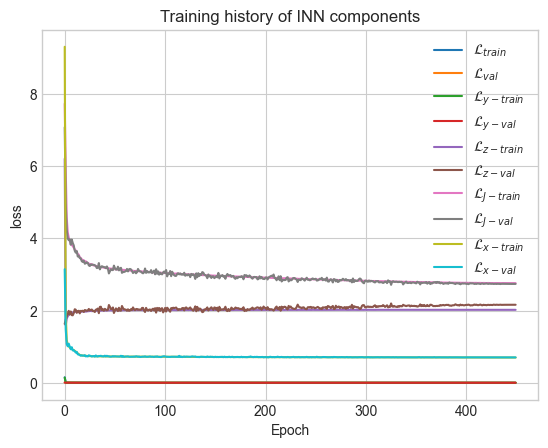

In [179]:
new_names = {
    'train_loss': f"$\mathcal{{L}}_{{train}}$",
    'val_loss': f"$\mathcal{{L}}_{{val}}$",
    'train_y_loss': f"$\mathcal{{L}}_{{y-train}}$",
    'val_y_loss': f"$\mathcal{{L}}_{{y-val}}$",
    'train_z_loss': f"$\mathcal{{L}}_{{z-train}}$",
    'val_z_loss': f"$\mathcal{{L}}_{{z-val}}$",
    'train_J_loss': f"$\mathcal{{L}}_{{J-train}}$",
    'val_J_loss': f"$\mathcal{{L}}_{{J-val}}$",
    'train_zero_loss': f"$\mathcal{{L}}_{{x-train}}$ ",
    'val_zero_loss': f"$\mathcal{{L}}_{{x-val}}$"
}
for k, v in multi_hist.items():
    #plt.figure(figsize=(8,5))
    if k in new_names:
        plt.plot(v, label=new_names[k])
        plt.xlabel('Epoch')
        plt.ylabel('loss')
        plt.legend()
        plt.grid()
    #plt.title(k)
plt.title("Training history of INN components")
plt.show()